  Property_ID  Area  Bedrooms  Bathrooms  Age     Location Property_Type  \
0    PROP0001  3712         4          3   36        Rural         House   
1    PROP0002  1591         4          1   35       Suburb         House   
2    PROP0003  1646         4          3   20        Rural         Villa   
3    PROP0004  4814         1          2   13  City Center         Villa   
4    PROP0005   800         4          2   38       Suburb     Apartment   

      Price  
0  22260000  
1  16057500  
2  12730000  
3  50840000  
4  10650000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Property_ID    300 non-null    object
 1   Area           300 non-null    int64 
 2   Bedrooms       300 non-null    int64 
 3   Bathrooms      300 non-null    int64 
 4   Age            300 non-null    int64 
 5   Location       300 non-null    object
 6   Proper

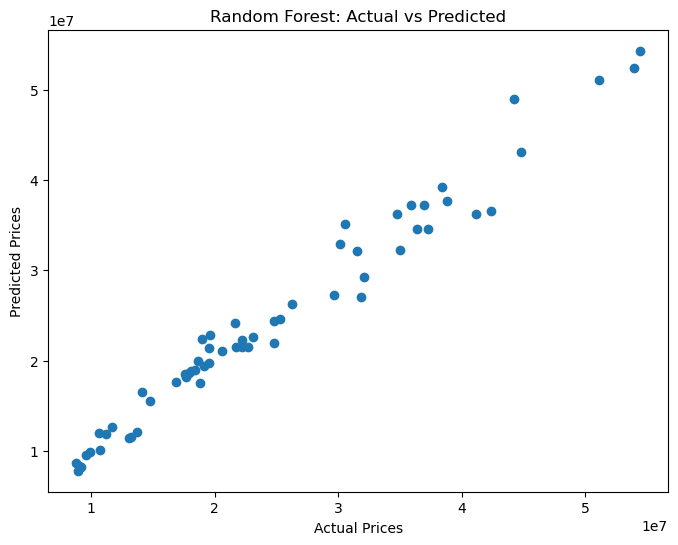


Feature Importance:
               Feature  Importance
0                 Area    0.693187
4       Location_Rural    0.201724
5      Location_Suburb    0.073616
1             Bedrooms    0.019140
3                  Age    0.008199
2            Bathrooms    0.002207
7  Property_Type_Villa    0.001143
6  Property_Type_House    0.000783


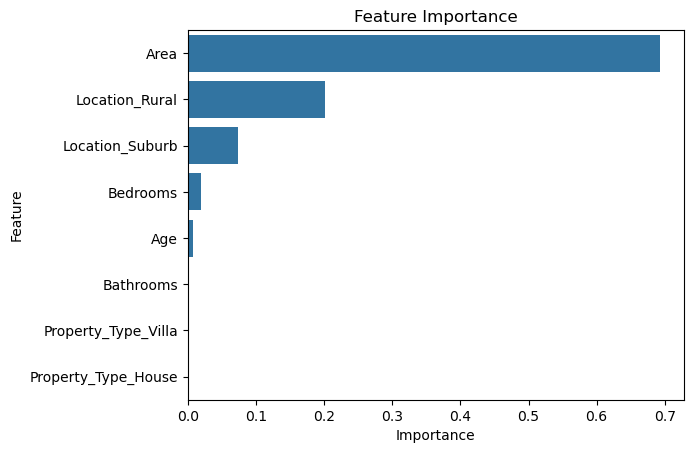


Best Model: Random Forest


In [1]:
# =========================================
# 📦 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# =========================================
# 📥 2. LOAD DATA
# =========================================
df = pd.read_csv("house_prices.csv")

print(df.head())
print(df.info())

# =========================================
# 🧹 3. DATA CLEANING
# =========================================

# Drop ID column
df = df.drop("Property_ID", axis=1)

# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

# Features & Target
X = df.drop("Price", axis=1)
y = df["Price"]

# =========================================
# ✂️ 4. TRAIN-TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# 🤖 5. LINEAR REGRESSION
# =========================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

# =========================================
# 📏 6. EVALUATION FUNCTION
# =========================================
def evaluate(y_test, preds, name):
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    print(f"\n{name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("R2 Score:", r2)
    
    return r2

# Evaluate Linear Regression
lr_r2 = evaluate(y_test, lr_preds, "Linear Regression")

# =========================================
# 🌳 7. DECISION TREE
# =========================================
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

dt_r2 = evaluate(y_test, dt_preds, "Decision Tree")

# =========================================
# 🌲 8. RANDOM FOREST
# =========================================
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_r2 = evaluate(y_test, rf_preds, "Random Forest")

# =========================================
# 📊 9. VISUALIZATION
# =========================================
plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted")
plt.savefig("predictions_vs_actual.png")
plt.show()

# =========================================
# 📊 10. FEATURE IMPORTANCE
# =========================================
importance = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feat_imp)

sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Feature Importance")
plt.show()

# =========================================
# 🏁 11. BEST MODEL
# =========================================
models = {
    "Linear Regression": lr_r2,
    "Decision Tree": dt_r2,
    "Random Forest": rf_r2
}

best_model = max(models, key=models.get)

print("\nBest Model:", best_model)